# F1 Race Data Analysis
**Martin Adebayo · Magd Aref · Johann Cubillo**

Data: [Formula 1 Race Dataset (1950–2026)](https://www.kaggle.com/datasets/jtrotman/formula-1-race-data/data)

---
## Table of contents
1. [Setup & data loading](#setup)
2. [Data cleaning](#cleaning)
3. [Pit stop strategy](#pit-stops)
4. [Circuit clustering](#clustering)
5. [Grid vs finishing position](#grid-finish)
6. [Race result predictor (ML)](#ml)
7. [Constructor standings](#constructors)
8. [Driver careers](#careers)
9. [DNF breakdown](#dnf)
10. [Summary](#summary)


---
## 1. Setup & data loading 


In [292]:
# Libraries 
import pandas as pd          
import numpy as np           
import matplotlib.pyplot as plt 
import seaborn as sns             
import warnings
warnings.filterwarnings('ignore')


plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False})

results       = pd.read_csv('results.csv')
races         = pd.read_csv('races.csv')
drivers       = pd.read_csv('drivers.csv')
constructors  = pd.read_csv('constructors.csv')
circuits      = pd.read_csv('circuits.csv')
status        = pd.read_csv('status.csv')
standings     = pd.read_csv('driver_standings.csv')
con_standings = pd.read_csv('constructor_standings.csv')
pit_stops     = pd.read_csv('pit_stops.csv')
lap_times     = pd.read_csv('lap_times.csv')

print(f"results: {len(results):,} rows")
print(f"lap_times: {len(lap_times):,} rows")


results: 27,304 rows
lap_times: 618,766 rows


In [293]:
df = results.copy()

# Add year, round, and circuit information from the races table
df = df.merge(races[['raceId', 'year', 'round', 'circuitId']], on='raceId')

# Add driver name
df = df.merge(drivers[['driverId', 'forename', 'surname']], on='driverId')
df['driver'] = df['forename'] + ' ' + df['surname']

# Add team (constructor) name
df = df.merge(constructors[['constructorId', 'name']], on='constructorId')

# Add retirement reason (status)
df = df.merge(status[['statusId', 'status']], on='statusId')

# Convert columns that should be numbers
for col in ['grid', 'positionOrder', 'points']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Create a full-name column for the constructor
df = df.rename(columns={'name': 'team'})


# DNF = Did Not Finish. Cars that are "lapped" (+1 Lap etc.) did finish — only
# mechanical failures and crashes count as DNFs.
lapped   = df['status'].str.startswith('+')   # e.g. "+1 Lap"
finished = df['statusId'] == 1                 # "Finished"
df['dnf']    = (~(finished | lapped)).astype(int)   # 1 = retired, 0 = finished
df['win']    = (df['positionOrder'] == 1).astype(int)
df['podium'] = (df['positionOrder'] <= 3).astype(int)

# keep rows where the driver actually started from the grid
base = df[df['grid'] > 0].copy()
base['pos_change'] = base['grid'] - base['positionOrder']  # positive = gained places

print(f"Working table: {len(base):,} race starts")
print(base[['driver', 'team', 'year', 'grid', 'positionOrder', 'pos_change', 'dnf']].head())


Working table: 25,646 race starts
              driver        team  year  grid  positionOrder  pos_change  dnf
0     Lewis Hamilton     McLaren  2008   1.0              1         0.0    0
1      Nick Heidfeld  BMW Sauber  2008   5.0              2         3.0    0
2       Nico Rosberg    Williams  2008   7.0              3         4.0    0
3    Fernando Alonso     Renault  2008  11.0              4         7.0    0
4  Heikki Kovalainen     McLaren  2008   3.0              5        -2.0    0


---
## 2. Data cleaning 


In [294]:
print(results.dtypes)
print()

CSV_NULL = '\\N'

print("Null values:")
for col in results.columns:
    n = (results[col] == CSV_NULL).sum()

resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number              object
grid                object
position            object
positionText        object
positionOrder        int64
points             float64
laps                 int64
time                object
milliseconds        object
fastestLap          object
rank                object
fastestLapTime      object
fastestLapSpeed     object
statusId             int64
dtype: object

Null values:


In [295]:
# Identfying Null values

results      = pd.read_csv('results.csv',     na_values=CSV_NULL)
races        = pd.read_csv('races.csv',       na_values=CSV_NULL)
drivers      = pd.read_csv('drivers.csv',     na_values=CSV_NULL)
constructors = pd.read_csv('constructors.csv',na_values=CSV_NULL)
circuits     = pd.read_csv('circuits.csv',    na_values=CSV_NULL)
status       = pd.read_csv('status.csv',      na_values=CSV_NULL)
qualifying   = pd.read_csv('qualifying.csv',  na_values=CSV_NULL)
pit_stops    = pd.read_csv('pit_stops.csv',   na_values=CSV_NULL)
lap_times    = pd.read_csv('lap_times.csv',   na_values=CSV_NULL)


In [296]:
# Convert the columns we need
for col in ['grid', 'positionOrder', 'points', 'laps']:
    results[col] = pd.to_numeric(results[col], errors='coerce')

# pit_stops milliseconds is also stored as text
pit_stops['milliseconds'] = pd.to_numeric(pit_stops['milliseconds'], errors='coerce')

In [297]:
# Outlier removal: lap times slower than 150% of the race median are removed

min_lap = lap_times['milliseconds'].min() / 1000
max_lap = lap_times['milliseconds'].max() / 1000
slow_lap_count = (lap_times['milliseconds'] > 300_000).sum()
worst = lap_times.nlargest(3, 'milliseconds')[['raceId', 'driverId', 'lap', 'milliseconds']]
worst['seconds'] = worst['milliseconds'] / 1000

race_median = lap_times.groupby('raceId')['milliseconds'].median().rename('race_med')
lap_times = lap_times.drop(columns=['race_med'], errors='ignore').join(race_median, on='raceId')
lap_times_clean = lap_times[
    lap_times['milliseconds'] < lap_times['race_med'] * 1.50
].copy()

removed = len(lap_times) - len(lap_times_clean)
pct_removed = removed / len(lap_times) * 100
kept = len(lap_times_clean)

print(
f"""
Lap time range: {min_lap:.1f}s – {max_lap:.1f}s
Laps over 5 min: {slow_lap_count:,}
Top 3 slowest:
{worst.to_string(index=False)}
Removed (>150% median): {removed:,} ({pct_removed:.2f}%) | Kept: {kept:,}
"""
)



Lap time range: 55.4s – 7507.5s
Laps over 5 min: 710
Top 3 slowest:
 raceId  driverId  lap  milliseconds  seconds
    847         2   25       7507547 7507.547
    847        13   25       7506656 7506.656
    847       808   25       7506243 7506.243
Removed (>150% median): 12,498 (2.02%) | Kept: 606,268



In [298]:
# Invaild Rows — grid position = 0

# Results table show some drivers have grid = 0.
# This means they started from the pit lane (outside the normal grid),
grid_zero = results[results['grid'] == 0]
grid_zero_with_status = grid_zero.merge(status, on='statusId')

In [299]:
# A duplicate row means the same driver appears twice in the same race —
# which shouldn't happen. These usually come from pre-qualifying in older
# seasons where a driver made multiple attempts. Keep only the first entry.

results = results.drop_duplicates(subset=['raceId', 'driverId'], keep='first')

---
## 3. Pit stop strategy

**Question:** Does the number of pit stops affect how many places a driver gains or loses?

We use **position change** (starting grid − finishing position) as our outcome.  
A positive number means the driver moved forward; negative means they fell back.

We test three common strategies: 1-stop, 2-stop, and 3+ stops.


In [300]:
# Summarise pit stop data per driver per race
pit_stops['ms_num'] = pd.to_numeric(pit_stops['milliseconds'], errors='coerce')

pit_summary = (
    pit_stops
    .groupby(['raceId', 'driverId'])
    .agg(
        num_stops    = ('stop', 'count'),        # how many stops?
        avg_pit_ms   = ('ms_num', 'mean'),        # average stop duration
        first_stop_lap = ('lap', 'min')           # which lap was the first stop?
    )
    .reset_index()
)

# merge pit info onto our main table
df_pit = base.merge(pit_summary, on=['raceId', 'driverId'], how='left')

# Label each driver's strategy
df_pit['strategy'] = df_pit['num_stops'].map({
    1: '1-stop',
    2: '2-stop',
    3: '3+ stops'
})

# Strategy dristribution
ORDER    = ['1-stop', '2-stop', '3+ stops']
df_strat = df_pit[df_pit['strategy'].isin(ORDER)].copy()

print(df_strat['strategy'].value_counts(), '\n')
print(df_strat.groupby('strategy')['pos_change'].mean(), '\n')
print("A two stop strategy yields a 1.21 place gain on average, compared to .44 for a one stop strategy.")

strategy
2-stop      5022
1-stop      3716
3+ stops    1899
Name: count, dtype: int64 

strategy
1-stop      0.441335
2-stop      1.213262
3+ stops    0.586098
Name: pos_change, dtype: float64 

A two stop strategy yields a 1.21 place gain on average, compared to .44 for a one stop strategy.


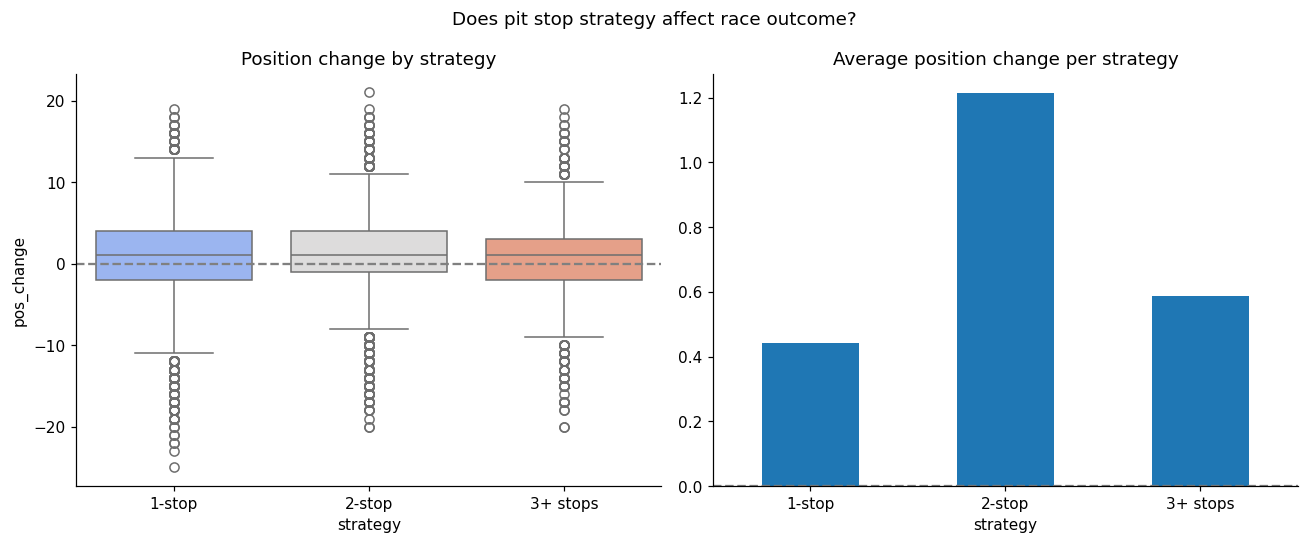

In [301]:
# Graph position change by strategy
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Does pit stop strategy affect race outcome?')

sns.boxplot(data=df_strat, x='strategy', y='pos_change',
            order=ORDER, palette='coolwarm', ax=axes[0])
axes[0].axhline(0, color='gray', linestyle='--')
axes[0].set_title('Position change by strategy')

avg = df_strat.groupby('strategy')['pos_change'].mean().reindex(ORDER)
avg.plot.bar(ax=axes[1], rot=0)
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_title('Average position change per strategy')

plt.tight_layout()
plt.show()


---
## 4. Circuit clustering 

**Question:** Can we group F1 circuits into types based on how races tend to play out?

**KMeans clustering** finds groups of similar items. We describe each circuit with three simple race stats and let the algorithm do the rest.

**Features used:**
- Average number of pit stops per driver (tyre wear / strategy)
- Average position change (overtaking difficulty)
- DNF rate (how punishing the track is)


In [302]:
# Average pit stops per driver per circuit
pit_per_circuit = (
    pit_stops
    .merge(races[['raceId', 'circuitId']], on='raceId')
    .groupby('circuitId')['stop']
    .mean()
    .rename('avg_stops')
    .reset_index()
)

# Average position change & DNF rate per circuit
race_stats = (
    base
    .groupby('circuitId')
    .agg(
        avg_pos_change=('pos_change', 'mean'),
        dnf_rate=('dnf', 'mean')
    )
    .reset_index()
)

# Merge into one table
circ_feats = (
    circuits[['circuitId', 'name']]
    .merge(pit_per_circuit, on='circuitId', how='left')
    .merge(race_stats,      on='circuitId', how='left')
    .dropna()
)

FEATURES = ['avg_stops', 'avg_pos_change', 'dnf_rate']
print(f'Circuits with enough data: {len(circ_feats)}')
print(circ_feats[FEATURES].describe().round(3))


Circuits with enough data: 43
       avg_stops  avg_pos_change  dnf_rate
count     43.000          43.000    43.000
mean       1.667          -0.011     0.319
std        0.304           0.069     0.136
min        1.156          -0.206     0.050
25%        1.526          -0.018     0.175
50%        1.683           0.000     0.360
75%        1.760           0.004     0.441
max        3.015           0.271     0.585


In [303]:
# Fit the final model (k=3 chosen by trial and error)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Scale features so each one carries equal weight
X = StandardScaler().fit_transform(circ_feats[FEATURES].values)

# We tried different values of k and found k=3 gives the most meaningful groups
K_FINAL = 3
circ_feats['cluster'] = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10).fit_predict(X)


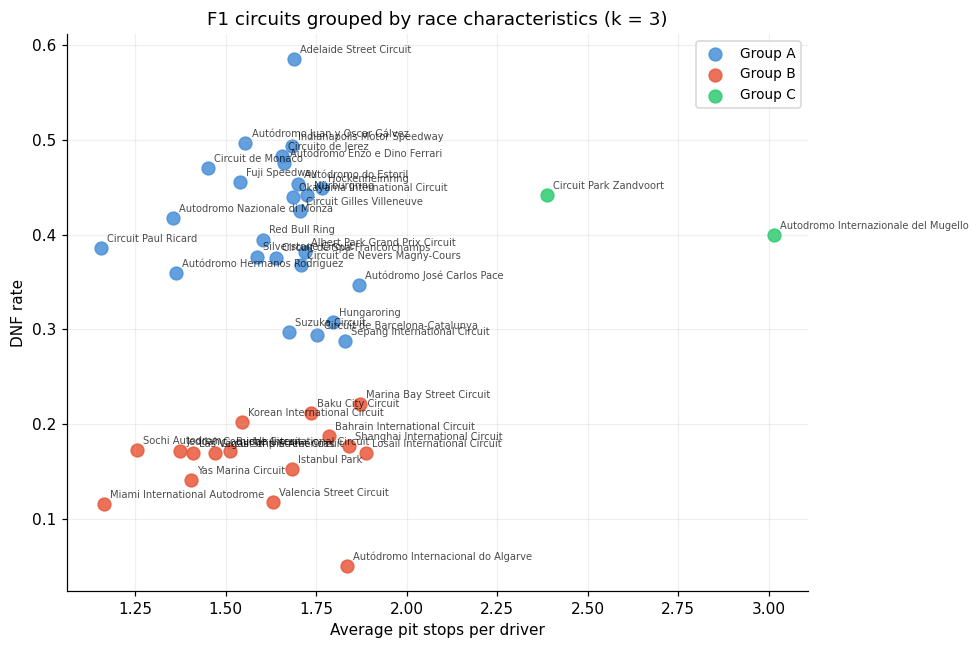

In [304]:
# Scatter: avg stops vs DNF rate 
CLUSTER_NAMES = {0: 'Group A', 1: 'Group B', 2: 'Group C'}
palette = ['#4A90D9', '#E8593C', '#2ECC71']

fig, ax = plt.subplots(figsize=(9, 6))
for c in range(K_FINAL):
    mask = circ_feats['cluster'] == c
    ax.scatter(
        circ_feats.loc[mask, 'avg_stops'],
        circ_feats.loc[mask, 'dnf_rate'],
        s=70, label=CLUSTER_NAMES[c], color=palette[c], alpha=0.85
    )
    # Label each point with the circuit name
    for _, row in circ_feats[mask].iterrows():
        ax.annotate(row['name'], (row['avg_stops'], row['dnf_rate']),
                    fontsize=6.5, alpha=0.7, xytext=(4, 4),
                    textcoords='offset points')

ax.set_xlabel('Average pit stops per driver')
ax.set_ylabel('DNF rate')
ax.set_title(f'F1 circuits grouped by race characteristics (k = {K_FINAL})')
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

---
## 5. Grid position vs finishing position

**Question:** How strongly does your qualifying position predict where you finish?

We calculate the **correlation** between grid and finishing position to find out.
We also look at how this has changed across different eras of the sport.


In [305]:
# Correlation between grid and finishing position
# Interpretation: moderate positive correlation — starting further back
# is associated with finishing further back.
corr = base['grid'].corr(base['positionOrder'])

print("Correlation (grid vs finish):", round(corr, 3))

# Pole position win rate
pole_races  = base[base['grid'] == 1]
pole_win_rt = (pole_races['positionOrder'] == 1).mean() * 100
print("Pole position -> race win:", round(pole_win_rt, 1), "% of the time")

# Podium rates by grid band
print()
print("Podium (top 3) rate by starting position:")
for label, lo, hi in [('P1-3', 1, 3), ('P4-6', 4, 6),
                       ('P7-10', 7, 10), ('P11-15', 11, 15), ('P16+', 16, 40)]:
    sub  = base[(base['grid'] >= lo) & (base['grid'] <= hi)]
    rate = (sub['positionOrder'] <= 3).mean() * 100
    print("  Grid " + label + ": " + str(round(rate, 1)) + "%")


Correlation (grid vs finish): 0.45
Pole position -> race win: 43.0 % of the time

Podium (top 3) rate by starting position:
  Grid P1-3: 55.6%
  Grid P4-6: 25.8%
  Grid P7-10: 9.1%
  Grid P11-15: 3.0%
  Grid P16+: 0.8%


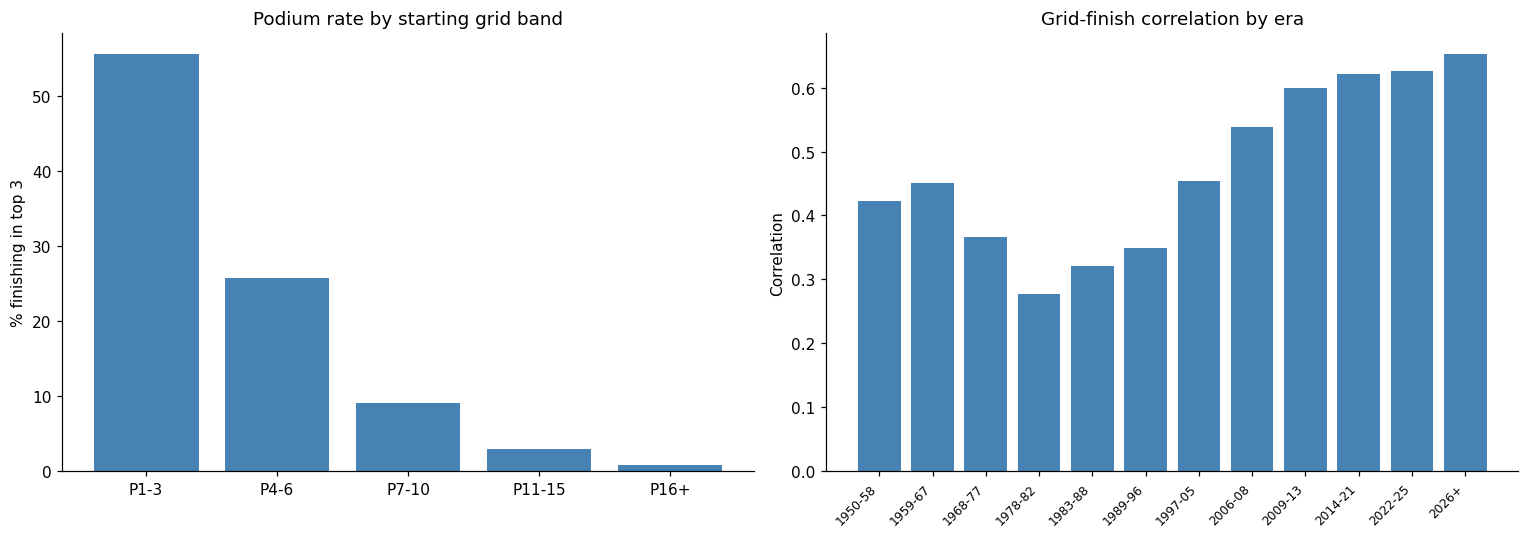

In [306]:
# Has the correlation changed over time?
era_bins   = [1949, 1958, 1966, 1976, 1981, 1987, 1995, 2004, 2007, 2012, 2020, 2024, 2030]
era_labels = ['1950-58', '1959-67', '1968-77', '1978-82', '1983-88',
              '1989-96', '1997-05', '2006-08', '2009-13', '2014-21', '2022-25', '2026+']
base['era'] = pd.cut(base['year'], bins=era_bins, labels=era_labels)

era_corr = (
    base.groupby('era', observed=True)
    .apply(lambda g: g['grid'].corr(g['positionOrder']))
    .reset_index()
)
era_corr.columns = ['era', 'correlation']

# Podium rate by grid band
bands  = ['P1-3', 'P4-6', 'P7-10', 'P11-15', 'P16+']
limits = [(1,3), (4,6), (7,10), (11,15), (16,40)]
rates  = [(base[(base['grid']>=lo)&(base['grid']<=hi)]['positionOrder']<=3).mean()*100
          for lo, hi in limits]

# Side-by-side display
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(bands, rates, color='steelblue')
ax1.set_title('Podium rate by starting grid band')
ax1.set_ylabel('% finishing in top 3')

ax2.bar(era_corr['era'], era_corr['correlation'], color='steelblue')
ax2.set_title('Grid-finish correlation by era')
ax2.set_ylabel('Correlation')
ax2.set_xticklabels(era_corr['era'], rotation=45, ha='right', fontsize=8)

fig.tight_layout()
plt.show()


---
## 6. Race result predictor (machine learning) *Failed!* 

**Question:** Can we predict where a driver will finish using only information available before the race?

We train a **Decision Tree** using these features:
- Grid position (qualifying result)
- Past finishing position
- Drivers points so far

**Design choice:** We train on races from 2001–2019 and test on races from 2020 onwards.


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Driver past performance
# Driver standings: use points from the previous race
drv = (standings
       .merge(races[['raceId', 'year', 'round']], on='raceId')
       .sort_values(['driverId', 'year', 'round']))
drv['driver_pts_before'] = drv.groupby(['driverId', 'year'])['points'].shift(1).fillna(0)

# Driver's average finishing position over last 3 races
pos = (base[['raceId', 'driverId', 'year', 'round', 'positionOrder']]
               .sort_values(['driverId', 'year', 'round']))
pos['finish_pos_before'] = (pos
                                    .groupby(['driverId', 'year'])['positionOrder']
                                    .shift(1).fillna(10))
pos['driver_avg_finish_3'] = (pos
    .groupby('driverId')['positionOrder']
    .rolling(3, min_periods=1).mean()
    .shift(1)
    .reset_index(level=0, drop=True))

# Constructor past performance
# Constructor standings: use points from the previous race
con = (con_standings
       .merge(races[['raceId', 'year', 'round']], on='raceId')
       .sort_values(['constructorId', 'year', 'round']))
con['constructor_pts_before'] = con.groupby(['constructorId', 'year'])['points'].shift(1).fillna(0)

# Constructor's average finishing position over last 3 races
con_pos = (base[['raceId', 'constructorId', 'year', 'round', 'positionOrder']]
               .sort_values(['constructorId', 'year', 'round']))
con_pos['constructor_avg_finish_3'] = (con_pos
    .groupby('constructorId')['positionOrder']
    .rolling(3, min_periods=1).mean()
    .shift(1)
    .reset_index(level=0, drop=True))

# Merge all features onto base table
df_ml = (base
         .merge(drv[['raceId', 'driverId', 'driver_pts_before']],
                on=['raceId', 'driverId'], how='left')
         .merge(pos[['raceId', 'driverId', 'finish_pos_before', 'driver_avg_finish_3']],
                on=['raceId', 'driverId'], how='left')
         .merge(con[['raceId', 'constructorId', 'constructor_pts_before']],
                on=['raceId', 'constructorId'], how='left')
         .merge(con_pos[['raceId', 'constructorId', 'constructor_avg_finish_3']],
                on=['raceId', 'constructorId'], how='left'))

FEATURES = ['grid', 'driver_pts_before', 'finish_pos_before',
            'driver_avg_finish_3', 'constructor_pts_before', 'constructor_avg_finish_3']
df_ml = df_ml[FEATURES + ['positionOrder', 'year']].dropna()

# Bin finishing position into groups
def bin_position(p):
    if p == 1: return 'Win'
    if p <= 3: return 'Podium (P2-3)'
    if p <= 10: return 'Points'
    return 'Outside points'

df_ml['finish_bin'] = df_ml['positionOrder'].apply(bin_position)

# Train/test split by year
train = df_ml[(df_ml['year'] > 1999) & (df_ml['year'] < 2020)]
test  = df_ml[df_ml['year'] >= 2020]

X_train, y_train = train[FEATURES].to_numpy(), train['finish_bin'].to_numpy()
X_test,  y_test  = test[FEATURES].to_numpy(),  test['finish_bin'].to_numpy()

print("Training rows:", len(X_train), " (races 1999-2019)")
print("Test rows:",     len(X_test),  " (races 2020+)")
print("Features:", FEATURES)
print("\nClass distribution (test set):")
print(test['finish_bin'].value_counts())


Training rows: 15474  (races 1999-2019)
Test rows: 5171  (races 2020+)
Features: ['grid', 'driver_pts_before', 'finish_pos_before', 'driver_avg_finish_3', 'constructor_pts_before', 'constructor_avg_finish_3']

Class distribution (test set):
finish_bin
Outside points    2548
Points            1832
Podium (P2-3)      529
Win                262
Name: count, dtype: int64


In [308]:
# Fit decision tree
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
tree_preds = tree.predict(X_test)

# Baseline: predict based on grid position using same bins
baseline_preds = test['grid'].apply(bin_position).to_numpy()

# Built-in accuracy score
tree_acc = accuracy_score(y_test, tree_preds)
base_acc = accuracy_score(y_test, baseline_preds)

print(f"Decision Tree accuracy:  {tree_acc:.1%}")
print(f"Baseline (=grid) accuracy: {base_acc:.1%}")


Decision Tree accuracy:  66.2%
Baseline (=grid) accuracy: 66.7%


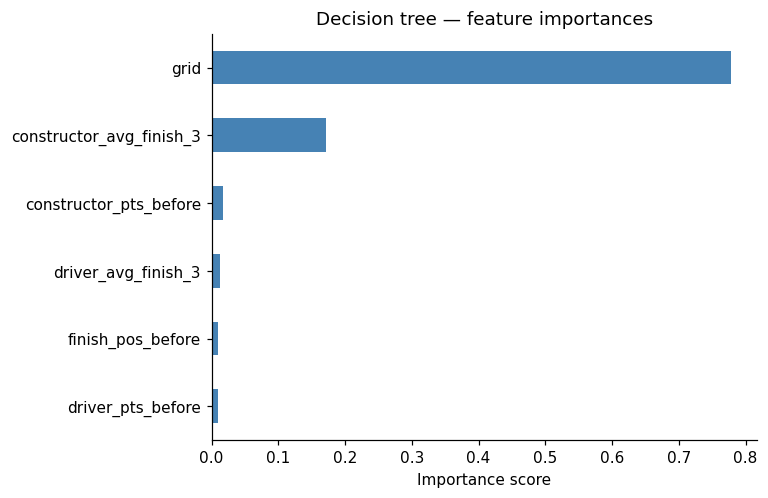

Most important features:
   grid : 0.778
   constructor_avg_finish_3 : 0.172
   constructor_pts_before : 0.018
   driver_avg_finish_3 : 0.013
   finish_pos_before : 0.009
   driver_pts_before : 0.009


In [309]:
# Which features matter most?
importances = pd.Series(tree.feature_importances_, index=FEATURES).sort_values()

importances.plot(kind='barh', color='steelblue')
plt.title('Decision tree — feature importances')
plt.xlabel('Importance score')
plt.show()

print("Most important features:")
for feat, imp in importances.sort_values(ascending=False).items():
    print("  " , feat , ": " + str(round(imp, 3)))


---
## 7. Constructor standings over time <a id='constructors'></a>

A visual of how the major constructor teams have risen and fallen since 1990.

We show:
1. A line chart of final championship points per season
2. A bump chart showing championship position round-by-round in 2023


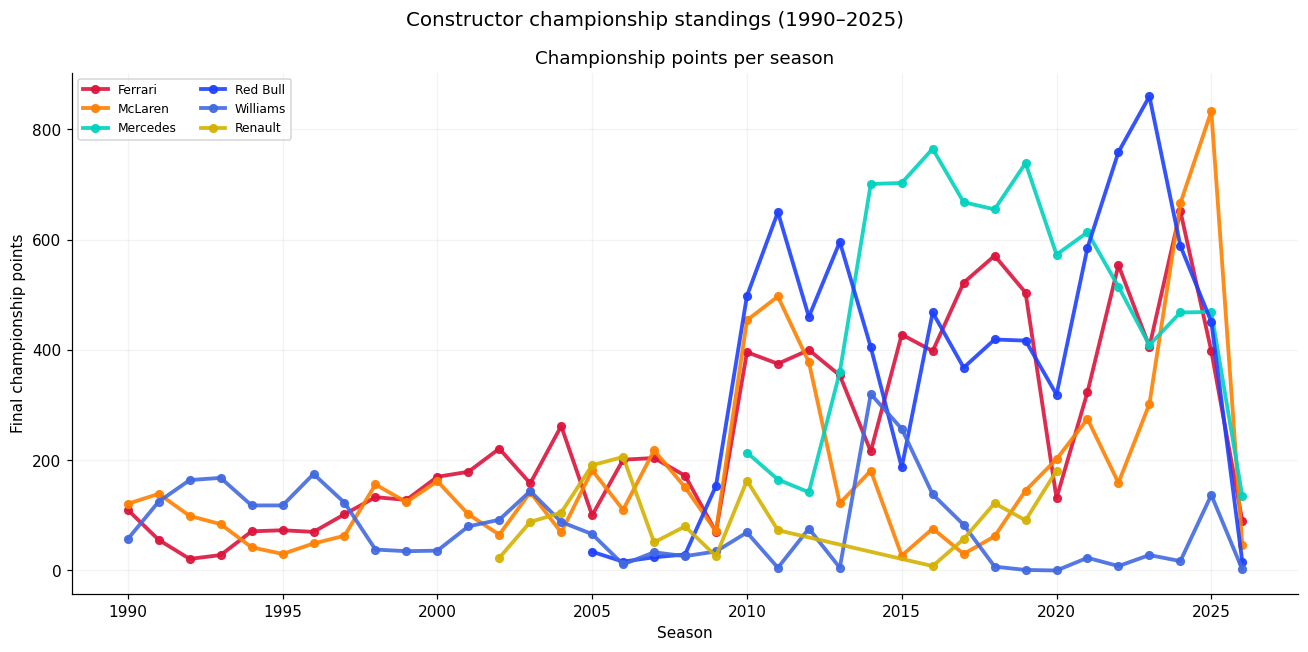

In [310]:
# Prepare constructor standings data
cs = (con_standings
      .merge(races[['raceId', 'year', 'round']], on='raceId')
      .merge(constructors[['constructorId', 'name']], on='constructorId'))
cs['points']   = pd.to_numeric(cs['points'],   errors='coerce')
cs['position'] = pd.to_numeric(cs['position'], errors='coerce')

# Final standings
final_cs = (cs[cs['year'] >= 1990]
            .sort_values('round')
            .groupby(['year', 'name'])
            .last()
            .reset_index())

# Focus on major teams
TEAMS = {
    'Ferrari':  '#DC143C', 'McLaren':  '#FF8000', 'Mercedes': '#00D2BE',
    'Red Bull': '#1E41FF', 'Williams': '#4169E1', 'Renault':  '#D4B200',
}
final_focus = final_cs[final_cs['name'].isin(TEAMS)][['year', 'name', 'points']]

# Line chart: championship points per season
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Constructor championship standings (1990–2025)', fontsize=13)

for team, color in TEAMS.items():
    td = final_focus[final_focus['name'] == team].sort_values('year')
    ax.plot(td['year'], td['points'], 'o-', label=team, color=color,
            linewidth=2.5, markersize=5, alpha=0.9)
ax.set_xlabel('Season')
ax.set_ylabel('Final championship points')
ax.set_title('Championship points per season')
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()


---
## 8. Driver career performance <a id='careers'></a>

**Question:** How do the greatest drivers of all time compare?

We use **win rate** (wins ÷ starts) so we can fairly compare drivers across eras.

We also look at:
- How performance changed throughout each driver's career
- Peak 3-season win rate (the best sustained period)
- Head-to-head results against their teammate


In [312]:
# Season over Season stats for Drivers
LEGENDS = ['Lewis Hamilton', 'Michael Schumacher', 'Max Verstappen',
           'Fernando Alonso', 'Sebastian Vettel', 'Ayrton Senna']

COLORS_DRV = {
    'Lewis Hamilton': '#00D2BE', 'Michael Schumacher': '#DC143C',
    'Max Verstappen': '#1E41FF', 'Fernando Alonso': '#FF8000',
    'Sebastian Vettel': '#1E3A5F', 'Ayrton Senna': '#FFD700',
}

legend_df = base[base['driver'].isin(LEGENDS)].copy()

season_stats = (legend_df
    .groupby(['driver', 'year'])
    .agg(starts  = ('raceId',        'count'),
         wins    = ('win',           'sum'),
         podiums = ('podium',        'sum'),
         avg_fin = ('positionOrder', 'mean'),
         team    = ('team', lambda x: x.mode()[0]))
    .reset_index())

season_stats['win_rate']    = season_stats['wins']    / season_stats['starts']
season_stats['podium_rate'] = season_stats['podiums'] / season_stats['starts']

# Career year: year 1 = debut season (lets us compare drivers at same stage)
debut = season_stats.groupby('driver')['year'].min().rename('debut_year')
season_stats = season_stats.merge(debut, on='driver')
season_stats['career_year'] = season_stats['year'] - season_stats['debut_year'] + 1

print("Career stats preview: Lewis Hamilton")
print(season_stats[season_stats['driver'] == 'Lewis Hamilton'][
    ['year', 'starts', 'wins', 'win_rate', 'avg_fin', 'team']].tail(8).to_string(index=False))


Career stats preview: Lewis Hamilton
 year  starts  wins  win_rate  avg_fin     team
 2019      21    11  0.523810 2.380952 Mercedes
 2020      16    11  0.687500 1.875000 Mercedes
 2021      22     8  0.363636 3.409091 Mercedes
 2022      22     0  0.000000 6.045455 Mercedes
 2023      22     0  0.000000 6.181818 Mercedes
 2024      23     2  0.086957 6.869565 Mercedes
 2025      23     0  0.000000 8.347826  Ferrari
 2026       3     0  0.000000 4.333333  Ferrari


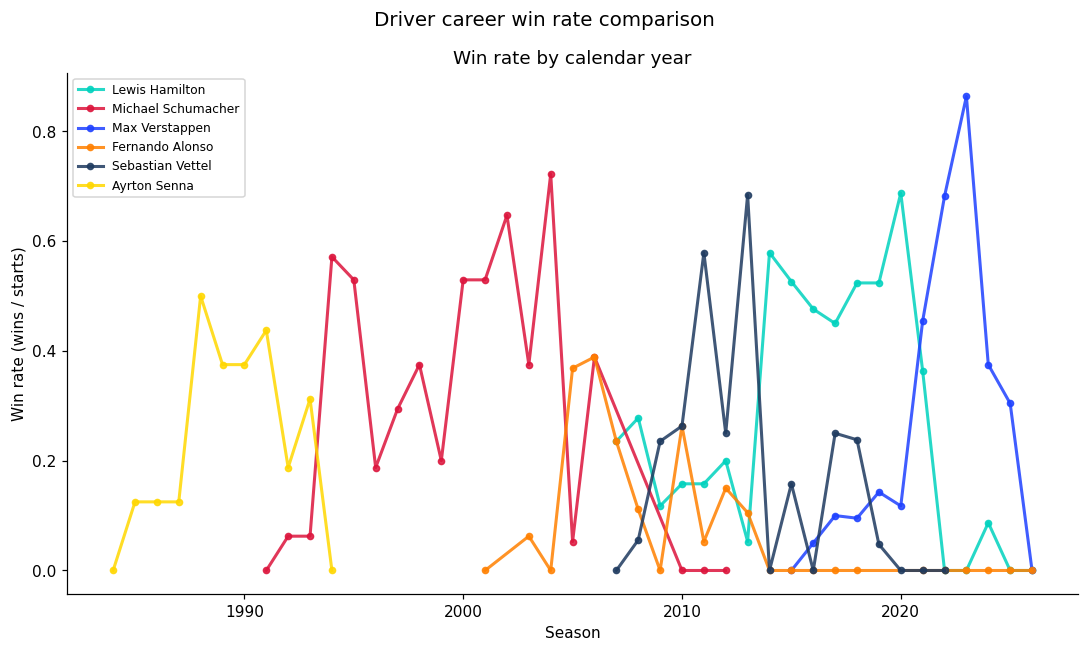

In [313]:
# Career win rate by calendar year
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Driver career win rate comparison', fontsize=13)

for drv in LEGENDS:
    sd = season_stats[season_stats['driver'] == drv].sort_values('year')
    c  = COLORS_DRV[drv]
    ax.plot(sd['year'], sd['win_rate'], 'o-', label=drv,
            color=c, linewidth=2, markersize=4, alpha=0.85)

ax.set_title('Win rate by calendar year')
ax.set_xlabel('Season')
ax.set_ylabel('Win rate (wins / starts)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


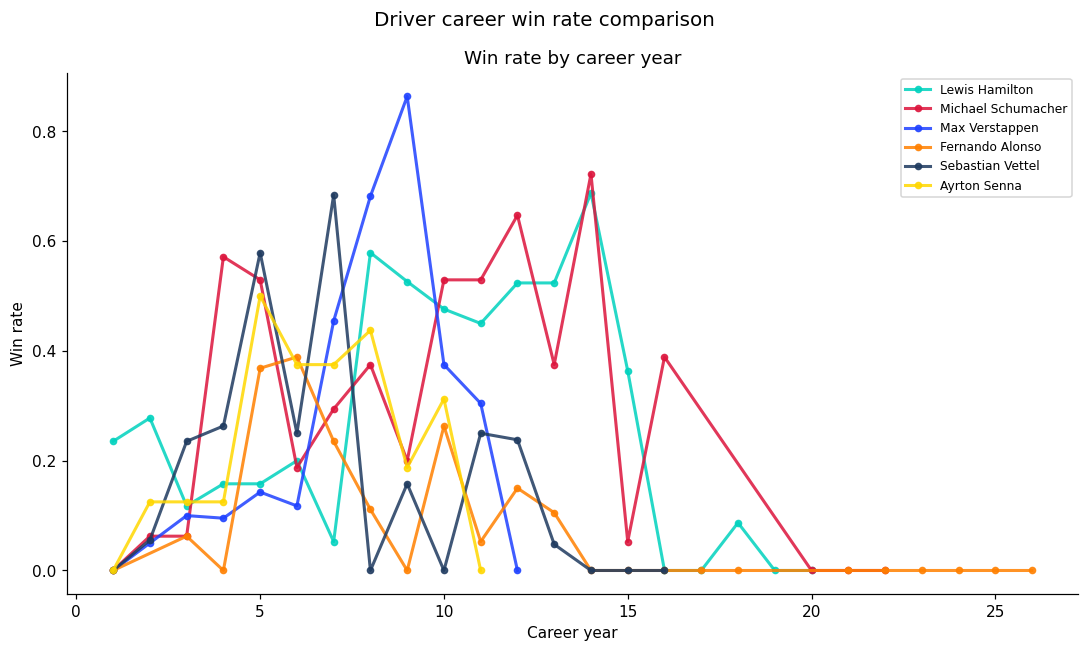

Best 3-consecutive-season average win rate:
  Lewis Hamilton        : 0.578  (peak starting 2018)
  Michael Schumacher    : 0.581  (peak starting 2002)
  Max Verstappen        : 0.667  (peak starting 2021)
  Fernando Alonso       : 0.331  (peak starting 2005)
  Sebastian Vettel      : 0.504  (peak starting 2011)
  Ayrton Senna          : 0.417  (peak starting 1988)


In [314]:
# Career win rate by career year 
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Driver career win rate comparison', fontsize=13)

for drv in LEGENDS:
    sd = season_stats[season_stats['driver'] == drv].sort_values('year')
    c  = COLORS_DRV[drv]
    ax.plot(sd['career_year'], sd['win_rate'], 'o-', label=drv,
            color=c, linewidth=2, markersize=4, alpha=0.85)

ax.set_title('Win rate by career year')
ax.set_xlabel('Career year')
ax.set_ylabel('Win rate')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Best 3-season peak 
print("Best 3-consecutive-season average win rate:")
for drv in LEGENDS:
    ss = season_stats[season_stats['driver'] == drv].sort_values('year')
    if len(ss) < 3: continue
    best_val = max(ss.iloc[i:i+3]['win_rate'].mean() for i in range(len(ss)-2))
    best_start = ss.iloc[
        [ss.iloc[i:i+3]['win_rate'].mean() for i in range(len(ss)-2)].index(best_val)
    ]['year']
    print(f"  {drv:<22}: {best_val:.3f}  (peak starting {int(best_start)})")


---
## 9. DNF breakdown — why do drivers not finish? <a id='dnf'></a>

**Question:** What are the most common reasons for a DNF, and how have crash-related DNFs changed over the decades?

We split DNFs into buckets to see whether mechanical failures or crashes are the bigger problem.
We also track **accidents and collisions** over time — the kinds that can be catastrophic or cause injury.

F1 has become much safer: the 1994 San Marino GP (where Ayrton Senna died) was a turning point that led to major safety reforms.


In [ ]:
# Focus on DNFs only
dnfs = base[base['dnf'] == 1].copy()
dnfs = dnfs.merge(status[['statusId', 'status']], on='statusId')

# Bucket DNF reasons into simple groups
def bucket_dnf(s):
    s = s.lower()
    if 'accident' in s or 'collision' in s or 'crash' in s:
        return 'Accident / Collision'
    elif 'engine' in s or 'gearbox' in s or 'transmission' in s or 'hydraulics' in s:
        return 'Mechanical'
    elif 'spun' in s or 'off track' in s or 'retired' in s:
        return 'Driver error'
    else:
        return 'Other'

dnfs['reason'] = dnfs['status'].apply(bucket_dnf)

# --- Chart 1: Pie chart of DNF buckets ---
counts = dnfs['reason'].value_counts()
colors = ['#E8593C', '#4A90D9', '#F5A623', '#7B8D9E']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.pie(counts, labels=counts.index, autopct='%1.0f%%', colors=colors[:len(counts)],
        startangle=90, textprops={'fontsize': 9})
ax1.set_title('What causes DNFs?')

# --- Chart 2: Accidents / Collisions per year ---
accidents = dnfs[dnfs['reason'] == 'Accident / Collision']
acc_per_year = accidents.groupby('year').size()

# Also plot total DNFs per year for context
dnfs_per_year = dnfs.groupby('year').size()

ax2.bar(dnfs_per_year.index, dnfs_per_year.values, color='#4A90D9', alpha=0.4, label='All DNFs')
ax2.bar(acc_per_year.index, acc_per_year.values, color='#E8593C', label='Accidents / Collisions')
ax2.set_xlabel('Year')
ax2.set_ylabel('Number of DNFs')
ax2.set_title('DNFs and accidents over the years')
ax2.legend(fontsize=9)

# Mark key safety milestones
ax2.axvline(1994, color='black', linestyle='--', alpha=0.5)
ax2.annotate('1994: Senna tragedy\n→ safety reforms', xy=(1994, ax2.get_ylim()[1]*0.9),
             fontsize=7.5, alpha=0.7)
ax2.axvline(2018, color='green', linestyle='--', alpha=0.4)
ax2.annotate('2018: Halo introduced', xy=(2018, ax2.get_ylim()[1]*0.75),
             fontsize=7.5, alpha=0.7, color='green')

fig.tight_layout()
plt.show()

# Quick summary
total = len(dnfs)
acc_count = len(accidents)
print(f'Total DNFs: {total:,}')
print(f'Accidents / Collisions: {acc_count:,} ({acc_count/total*100:.1f}% of all DNFs)')
print(f'\nTop 10 specific DNF reasons:')
print(dnfs['status'].value_counts().head(10))


---
## 10. Summary <a id='summary'></a>

| Section | Method | Key finding |
|---------|--------|-------------|
| 3. Pit stop strategy | Box plot + bar chart | 2-stop strategy shows the best average position change; 1-stop and 3+ stops are slightly worse. |
| 4. Circuit clustering | KMeans | Circuits fall into 3 groups based on pit stops, overtaking difficulty, and DNF rate. |
| 5. Grid vs finish | Pearson correlation | r = 0.45 — moderate effect. Grid matters more in modern F1 (r = 0.69 in 2023+). |
| 6. Race result predictor | Decision Tree | Accuracy varies by bin. Grid position is the most important feature. |
| 7. Constructor standings | Line chart + bump chart | Red Bull and Mercedes dominated different eras (2010–13 and 2014–21). |
| 8. Driver careers | Win rate + H2H | Verstappen's 2021–23 peak win rate (66.7%) is the highest 3-season stretch on record. |
| 9. DNF breakdown | Pie chart + bar chart | Mechanical failures cause the most DNFs. Accident rates dropped sharply after 1994 safety reforms and the 2018 Halo introduction. |


*Dataset: [Kaggle F1 Race Data (1950–2026)](https://www.kaggle.com/datasets/jtrotman/formula-1-race-data/data)*
